In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
import os
import random
import pdb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("使用设备:", device)

# 数据增强与预处理
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# 加载 Food101
train_dataset = datasets.Food101(root='./data', split='train', download=True, transform=train_transform)
test_dataset = datasets.Food101(root='./data', split='test', download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=10)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=10)

使用设备: cuda


In [2]:
"""
ResNet50
├── 入口层
│   └── Conv -> BN -> ReLU -> MaxPool

├── Stage 1 (3 Blocks)
│   └── 每个block: [1x1, 64] -> [3x3, 64] -> [1x1, 256]

├── Stage 2 (4 Blocks)
│   └── 每个block: [1x1, 128] -> [3x3, 128] -> [1x1, 512]

├── Stage 3 (6 Blocks)
│   └── 每个block: [1x1, 256] -> [3x3, 256] -> [1x1, 1024]

├── Stage 4 (3 Blocks)
│   └── 每个block: [1x1, 512] -> [3x3, 512] -> [1x1, 2048]

└── 输出层
    └── AvgPool -> Linear (101 classes)
"""

'\nResNet50\n├── 入口层\n│   └── Conv -> BN -> ReLU -> MaxPool\n\n├── Stage 1 (3 Blocks)\n│   └── 每个block: [1x1, 64] -> [3x3, 64] -> [1x1, 256]\n\n├── Stage 2 (4 Blocks)\n│   └── 每个block: [1x1, 128] -> [3x3, 128] -> [1x1, 512]\n\n├── Stage 3 (6 Blocks)\n│   └── 每个block: [1x1, 256] -> [3x3, 256] -> [1x1, 1024]\n\n├── Stage 4 (3 Blocks)\n│   └── 每个block: [1x1, 512] -> [3x3, 512] -> [1x1, 2048]\n\n└── 输出层\n    └── AvgPool -> Linear (101 classes)\n'

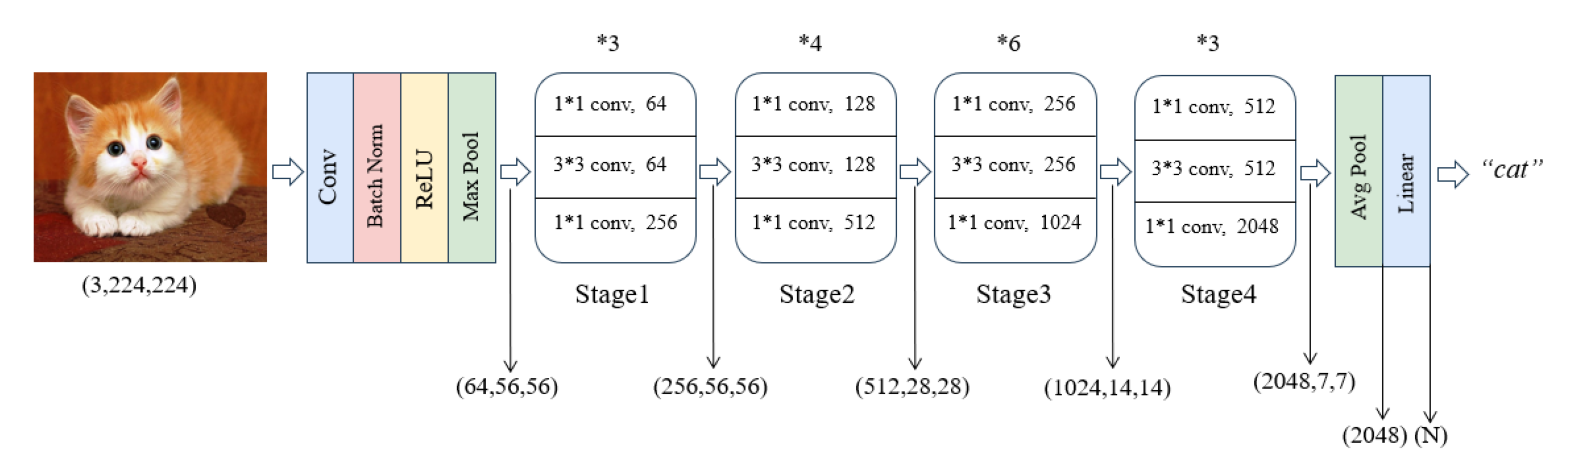

In [3]:
# 打印ResNet结构图
plt.figure(figsize=(20, 10))
plt.imshow(Image.open('4_7/architecture/resnet50.png'))
plt.axis('off')
plt.show()

In [ ]:
# 每个Block

class Bottleneck(nn.Module):
    expansion = 4  # ！！升维: 输出通道数是输入通道数的 4 倍， 只会在每个block的最后一个卷积层使用

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # 1x1 卷积
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
    
        # 3x3 卷积
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 1x1 卷积（升维）
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample  # !! 只会在每个stage的第1个block中使用

    def forward(self, x):
        identity = x
        
        ######
        out = self.relu(self.bn1(self.conv1(x))) # 第一个1*1卷积
        out = self.relu(self.bn2(self.conv2(out))) # 3*3卷积
        # TODO: 实现最后一个1*1卷积: conv3 -> bn3 (Hint: 先卷积再BN, 不需要ReLU)
        ######

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        return self.relu(out)

In [ ]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.in_channels = 64
        
        # 入口层
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Stage 1-4
        self.layer1 = self._make_layer(block, 64,  layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # 输出层
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = [block(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        # print("初步特征提取形状:", x.shape)
        
        ######
        # TODO: 实现从Stage1-4, 以及拉伸分类 的前向传播逻辑
        # Hint: 依次调用 self.layer1, self.layer2, self.layer3, self.layer4, self.avgpool, self.fc
        # Hint: self.avgpool的输出需要拉平(flatten)
        ######
        
        return x

def resnet50(num_classes=1000):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes)

model = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000) # ResNet50 标准配置

In [ ]:
# 获取ResNet 在 Imagenet 上预训练的权重
# pretrained_state_dict = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).state_dict()
# 如果从本地加载
pretrained_state_dict = torch.load("4_7/ckpt/resnet50-imagenet-pretrained.pth")

# 载入到我们的模型中
model.load_state_dict(pretrained_state_dict)

# 修改最后的全连接层，适配Food101 （1000类→101类)
model.fc = nn.Linear(model.fc.in_features, 101)
model = model.to(device)

In [7]:
print(model)

# 打开text editor, 或 打开 4_7/architecture/resnet50.md, 验证模型结构

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model):
    size = len(dataloader.dataset)
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()  
    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}% \n")

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 记得要把刚才那些print注释掉!, 否则你会输出一大堆训练细节

# 由于加载了在ImageNet上的预训练权重，训练时只需要微调5个epoch左右, 就可以达到很不错的效果了
epochs = 1
# 课堂上由于时间原因, 可调整为1个

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer)
    test(test_loader, model)
    
torch.save(model.state_dict(), f'ResNet.pth')
print(f"训练完成! 保存到了ResNet.pth")
# 准确率70%以上, 是正常的

Epoch 1
-------------------------------
loss: 4.702854  [   64/75750]
loss: 2.755137  [ 6464/75750]
loss: 1.912686  [12864/75750]
loss: 1.867252  [19264/75750]
loss: 1.752663  [25664/75750]
loss: 1.578147  [32064/75750]
loss: 1.700636  [38464/75750]
loss: 1.261864  [44864/75750]
loss: 1.261130  [51264/75750]
loss: 1.269458  [57664/75750]
loss: 1.550375  [64064/75750]
loss: 0.986745  [70464/75750]
Test Accuracy: 73.4% 

Epoch 2
-------------------------------
loss: 1.083777  [   64/75750]
loss: 0.961920  [ 6464/75750]
loss: 1.034880  [12864/75750]
loss: 1.027075  [19264/75750]
loss: 1.246117  [25664/75750]
loss: 0.972393  [32064/75750]
loss: 0.749966  [38464/75750]
loss: 1.085954  [44864/75750]
loss: 0.929699  [51264/75750]
loss: 0.932290  [57664/75750]
loss: 1.140273  [64064/75750]
loss: 1.289546  [70464/75750]
Test Accuracy: 77.6% 

Epoch 3
-------------------------------
loss: 0.715304  [   64/75750]
loss: 0.684484  [ 6464/75750]
loss: 1.011836  [12864/75750]
loss: 0.630031  [19264/7

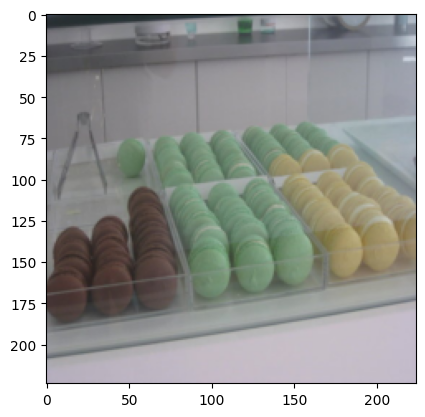

真实标签:  马卡龙
预测标签:  马卡龙


In [ ]:
# 取样本，作测试
import random

food101_classes = [
    "苹果派", "猪小排", "巴克拉瓦", "生牛肉片", "鞑靼牛肉", 
    "甜菜沙拉", "贝涅饼", "石锅拌饭", "面包布丁", "早餐卷饼", 
    "意式烤面包", "凯撒沙拉", "奶油甜馅煎饼卷", "卡普里沙拉", "胡萝卜蛋糕", 
    "柠檬汁腌鱼", "芝士蛋糕", "奶酪拼盘", "咖喱鸡", "鸡肉法式馅饼", 
    "鸡翅", "巧克力蛋糕", "巧克力慕斯", "吉拿棒", "蛤蜊浓汤", 
    "会所三明治", "蟹肉饼", "法式烤布蕾", "库克太太三明治", "杯子蛋糕", 
    "恶魔蛋", "甜甜圈", "饺子", "毛豆", "班尼迪克蛋", 
    "焗蜗牛", "炸豆丸子", "菲力牛排", "炸鱼薯条", "鹅肝", 
    "薯条", "法式洋葱汤", "法式吐司", "炸鱿鱼", "炒饭", 
    "冷冻酸奶", "大蒜面包", "意式土豆团子", "希腊沙拉", "烤奶酪三明治", 
    "烤三文鱼", "鳄梨酱", "煎饺", "汉堡", "酸辣汤", 
    "热狗", "墨西哥庄园蛋", "鹰嘴豆泥", "冰激凌", "意式肉酱千层面", 
    "龙虾浓汤", "龙虾卷三明治", "奶酪通心粉", "马卡龙", "味噌汤", 
    "贻贝", "墨西哥玉米片", "欧姆蛋", "洋葱圈", "生蚝", 
    "泰式炒河粉", "西班牙海鲜饭", "烤薄饼", "意式奶冻", "北京烤鸭", 
    "越南河粉", "披萨", "猪排", "普丁", "上等牛肋排", 
    "撕扯猪肉三明治", "拉面", "意式馄饨", "红丝绒蛋糕", "意式烩饭", 
    "萨莫萨三角炸饺", "生鱼片", "扇贝", "海藻沙拉", "鲜虾玉米粥", 
    "意式肉酱面", "意式奶油培根面", "春卷", "牛排", "草莓蛋糕", 
    "寿司", "墨西哥夹饼", "章鱼烧", "提拉米苏", "鞑靼金枪鱼", 
    "华夫饼"
]

# 随机挑选一个test sample
test_idx = random.randint(0, len(test_dataset)-1) # 随机生成idx
x, y = test_dataset[test_idx][0], test_dataset[test_idx][1] # x是图像, y是标签
x_display = x.permute(1, 2, 0)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
x_display = x_display * std + mean
x_display = torch.clamp(x_display, 0, 1)
plt.imshow(x_display)
plt.show()
print("真实标签: ", food101_classes[y])
print("预测标签: ", food101_classes[model(x.unsqueeze(0).to(device)).argmax(1).item()])

# 如果有预测不对, 多试几次